In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * # mae imported

from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA, ARIMA, AutoTBATS

In [9]:
# import the ADF test
from statsmodels.tsa.stattools import adfuller

# create a function that returns the necessary metrics to test stationarity
def test_stationarity(timeseries):
    dftest_initial = adfuller(timeseries)
    dfoutput_initial = pd.Series(dftest_initial[0:4], 
          index=['Statistical Test', 
                 'p-value', 
                 '#Lags used', 
                 'Number of observations'
                 ])
    for key, value in dftest_initial[4].items():
        dfoutput_initial['Critical value ' + key] = value
    print(dfoutput_initial)
    print('\n')

In [10]:
data = pd.read_csv("../../Downloads/iex_dam_feb_mar_2026.csv")

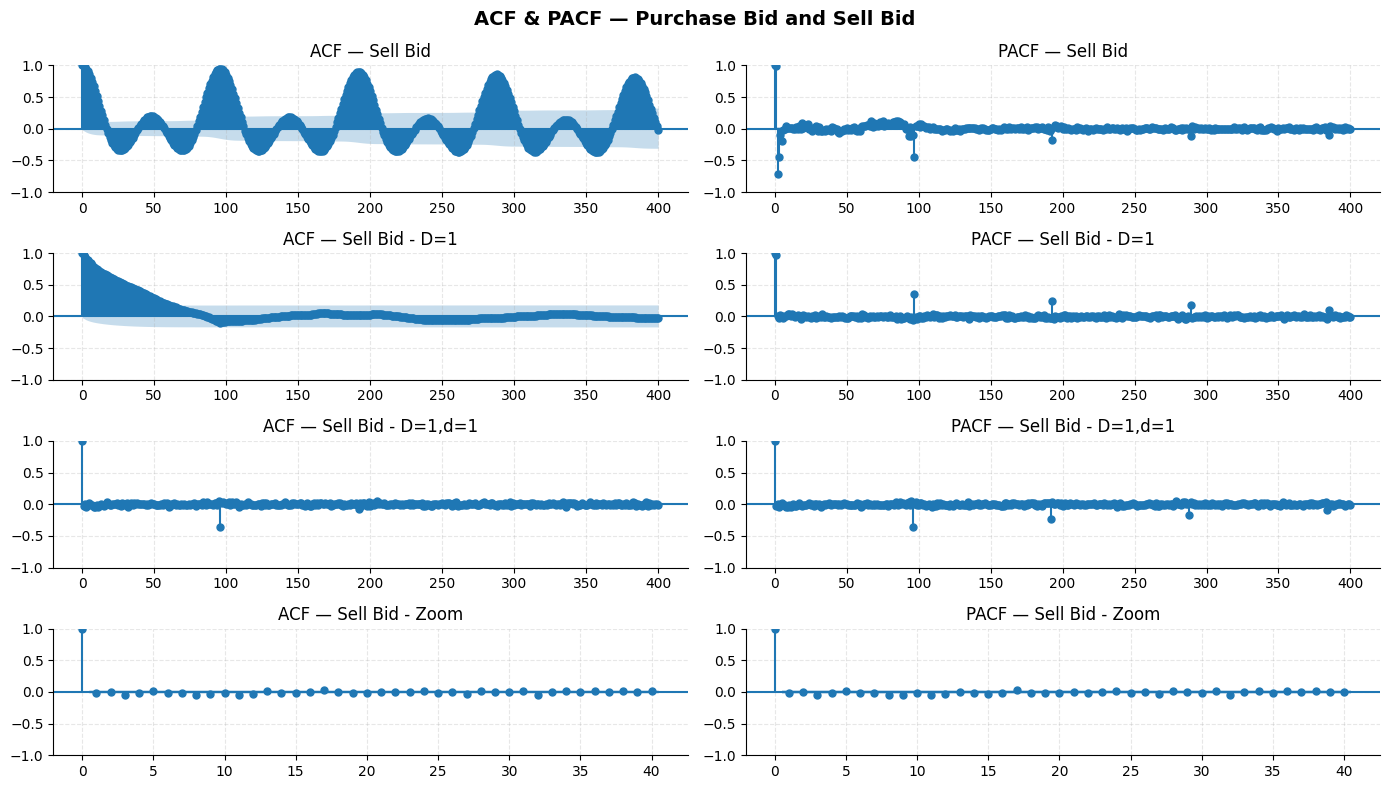

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(14, 8))
fig.suptitle("ACF & PACF — Purchase Bid and Sell Bid", fontsize=14, fontweight="bold")

plot_acf(data["sell_bid"].dropna(),  lags=400, ax=axes[0, 0], title="ACF — Sell Bid")
plot_pacf(data["sell_bid"].dropna(), lags=400, ax=axes[0, 1], title="PACF — Sell Bid")
plot_acf(data["sell_bid"].diff(96).dropna(),  lags=400, ax=axes[1, 0], title="ACF — Sell Bid - D=1")
plot_pacf(data["sell_bid"].diff(96).dropna(), lags=400, ax=axes[1, 1], title="PACF — Sell Bid - D=1")
plot_acf(data["sell_bid"].diff(96).diff().dropna(),  lags=400, ax=axes[2, 0], title="ACF — Sell Bid - D=1,d=1")
plot_pacf(data["sell_bid"].diff(96).diff().dropna(), lags=400, ax=axes[2, 1], title="PACF — Sell Bid - D=1,d=1")
plot_acf(data["sell_bid"].diff(96).diff().dropna(),  lags=40, ax=axes[3, 0], title="ACF — Sell Bid - Zoom")
plot_pacf(data["sell_bid"].diff(96).diff().dropna(), lags=40, ax=axes[3, 1], title="PACF — Sell Bid - Zoom")

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

From the plots in data exploration notebook, it's evident that we should focus on modeling SARIMA time series.
- Now, SARIMA requires 7 parameters (p,d,q)(P,D,Q)m
- Here m is clearly 96 (1 day) since cyclicity is evident in a day.
- We will first start with D and d to reach stationarity. 
- After differencing with D=1, I am seeing hints of stationarity achieved. 
- Will then difference again with d=1, I am seeing ACF decaying exponentially now.
- Then I am seeing spikes at lag 96 in ACF and multiples of 96 in PACF. This gives me my Q=1 and P=1,2,3...
- Then, to get small p and q, we will zoom and see there are no significant spikes, so we will keep them 0 or 1 for now.

Although to have a baseline to compare against, I will first implement baseline models as well.

Now, in order to use a faster library of StatsForecast, I need to transform the columns as below

In [12]:
data = data.rename(columns={
    'period_start': 'ds',  # Your timestamp
    'sell_bid': 'y'             # The target value you want to plot (Market Clearing Price)
})
filtered_data = data[[ "ds", "y" ]]
filtered_data['unique_id'] = 'series_1'
filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_81603/2219303837.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['unique_id'] = 'series_1'
/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_81603/2219303837.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])


### Predict a week in future

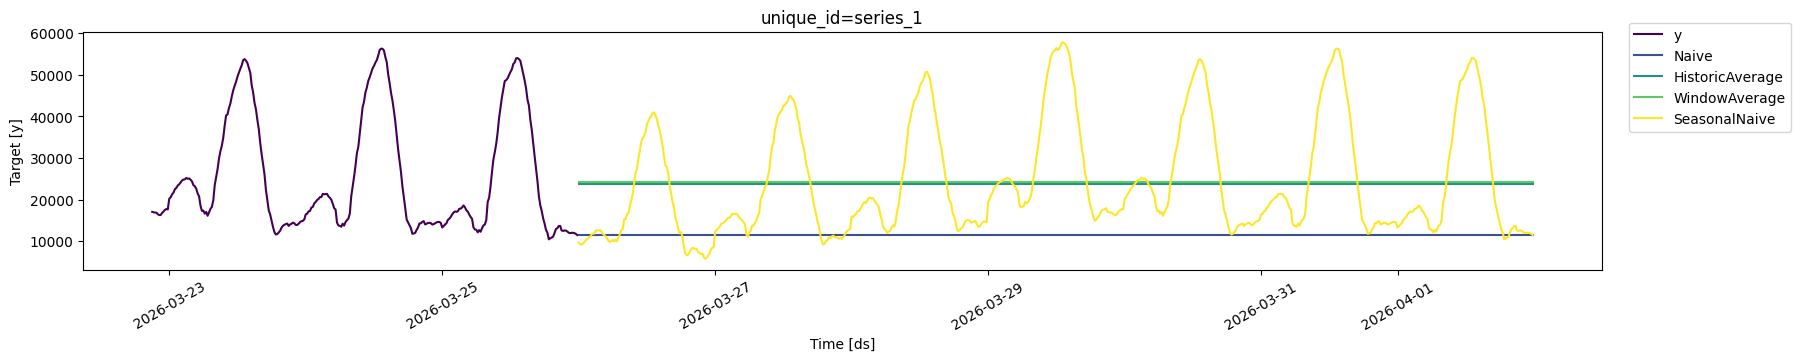

In [14]:
horizon = 96*7

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=96*7),
    SeasonalNaive(season_length=96*7)
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=filtered_data)
preds = sf.predict(h=horizon)

plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=300, 
    palette="viridis")

## Evaluating last 7 day by training on Total-7 days

In [15]:
test = filtered_data.tail(horizon)
train = filtered_data.drop(test.index).reset_index(drop=True)

sf.fit(df=train)
preds = sf.predict(h=horizon)
test_predictions_v1 = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

metrics = evaluate(
    test_predictions_v1,
    metrics=[mae],
)
metrics.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,series_1,mae,16414.492857,11305.165066,10964.782719,8845.088542


In [16]:
metrics = metrics.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
metrics

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,16414.492857,11305.165066,10964.782719,8845.088542


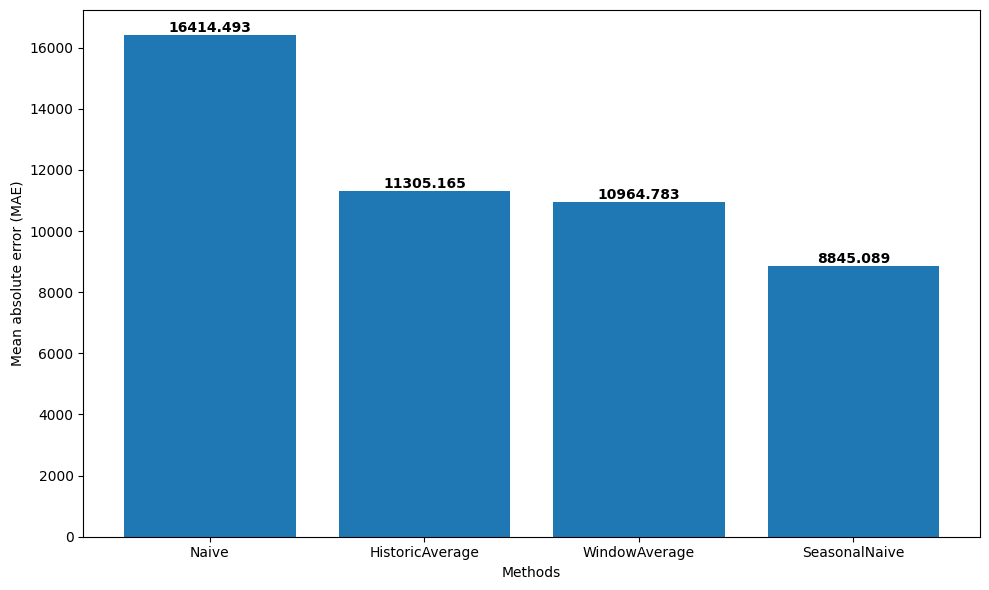

In [17]:
methods = metrics.columns[1:].tolist()  
values = metrics.iloc[0, 1:].tolist() 

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

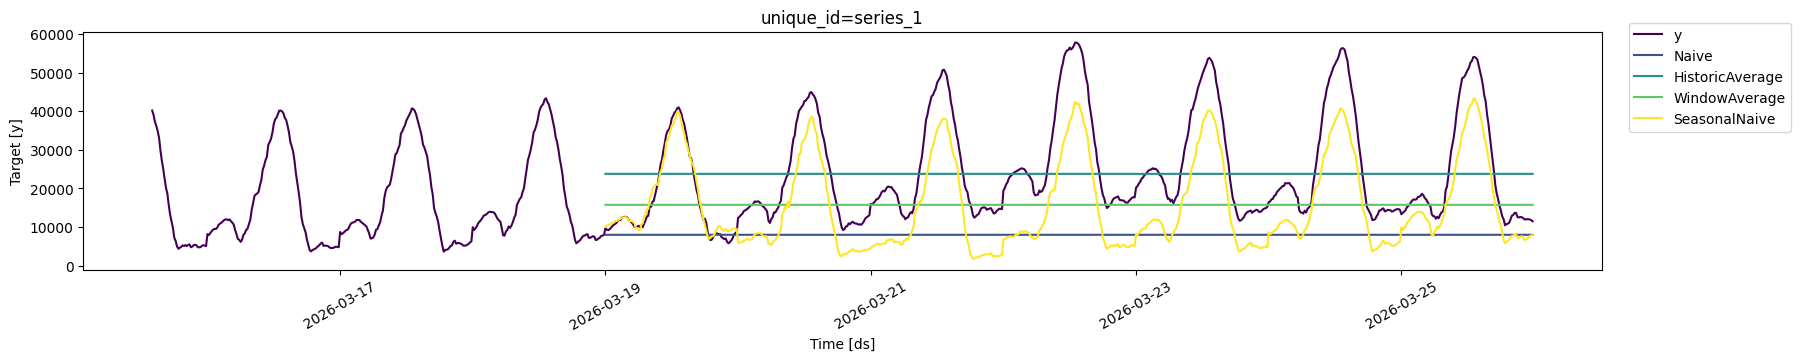

In [18]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=1000, 
    palette="viridis")

### SARIMA - last 7 days

In [19]:
horizon = 96*7

models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)"),
    # ARIMA(order=(1,1,1), season_length=96, seasonal_order=(2, 1, 1), alias="SARIMA (1,1,1,2,1,1,96)"),
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96)"),
]

sf_arima = StatsForecast(models=models, freq="15min")
sf_arima.fit(df=train)
preds = sf_arima.predict(h=horizon)

test_predictions_v2 = pd.merge(test_predictions_v1, preds, 'inner', ['ds', 'unique_id'])

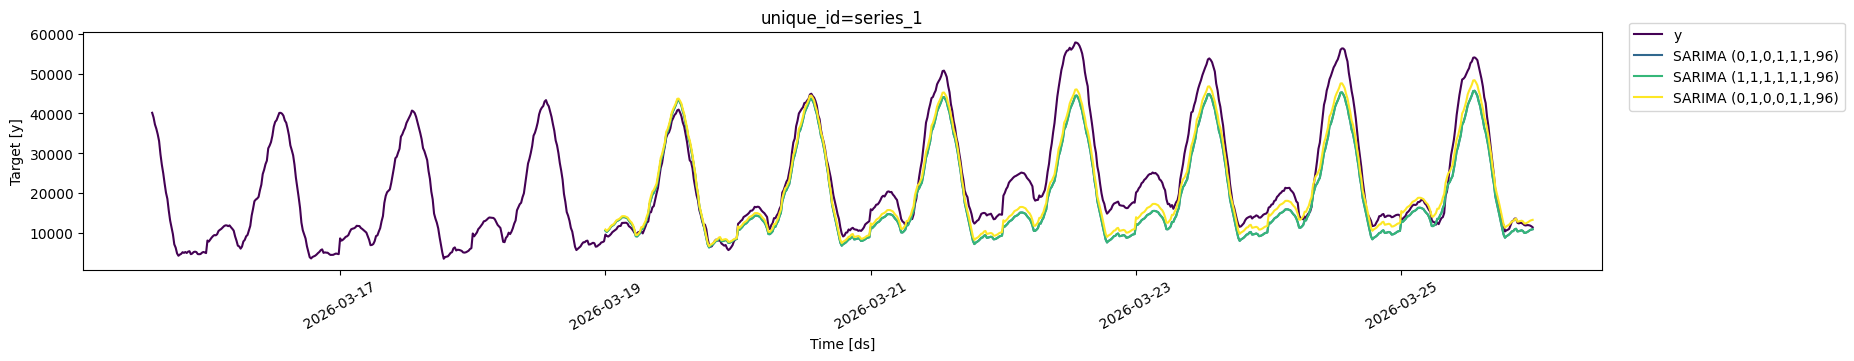

In [20]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=1000, 
    palette="viridis")

In [22]:
metrics = evaluate(
    test_predictions_v2,
    metrics=[mae],
)
metrics

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)","SARIMA (0,1,0,0,1,1,96)"
0,series_1,mae,16414.492857,11305.165066,10964.782719,8845.088542,5029.675394,5035.193702,3961.531543


### SARIMA with Exogeneous variables - last 7 days

In [23]:
data_with_exog = filtered_data.copy()
# data_with_exog["period_enum"] = data_with_exog["ds"].dt.hour * 4 + data_with_exog["ds"].dt.minute // 15 + 1
data_with_exog["weekday_enum"] = data_with_exog["ds"].dt.weekday + 1

test = data_with_exog.groupby("unique_id").tail(horizon)
train = data_with_exog.drop(test.index).reset_index(drop=True)

futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

,ds,unique_id,weekday_enum
4416,2026-03-19 00:00:00,series_1,4
4417,2026-03-19 00:15:00,series_1,4
4418,2026-03-19 00:30:00,series_1,4
4419,2026-03-19 00:45:00,series_1,4
4420,2026-03-19 01:00:00,series_1,4


In [24]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96) exog")
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=train)
exog_preds = sf.predict(h=horizon, X_df=futr_exog_df)

test_predictions_v3 = pd.merge(test_predictions_v2, exog_preds,  'inner', ['ds', 'unique_id'])

In [25]:
# arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
metrics = evaluate(
    test_predictions_v3,
    metrics=[mae],
)
metrics

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)","SARIMA (0,1,0,0,1,1,96)","SARIMA (0,1,0,0,1,1,96) exog"
0,series_1,mae,16414.492857,11305.165066,10964.782719,8845.088542,5029.675394,5035.193702,3961.531543,3776.542392


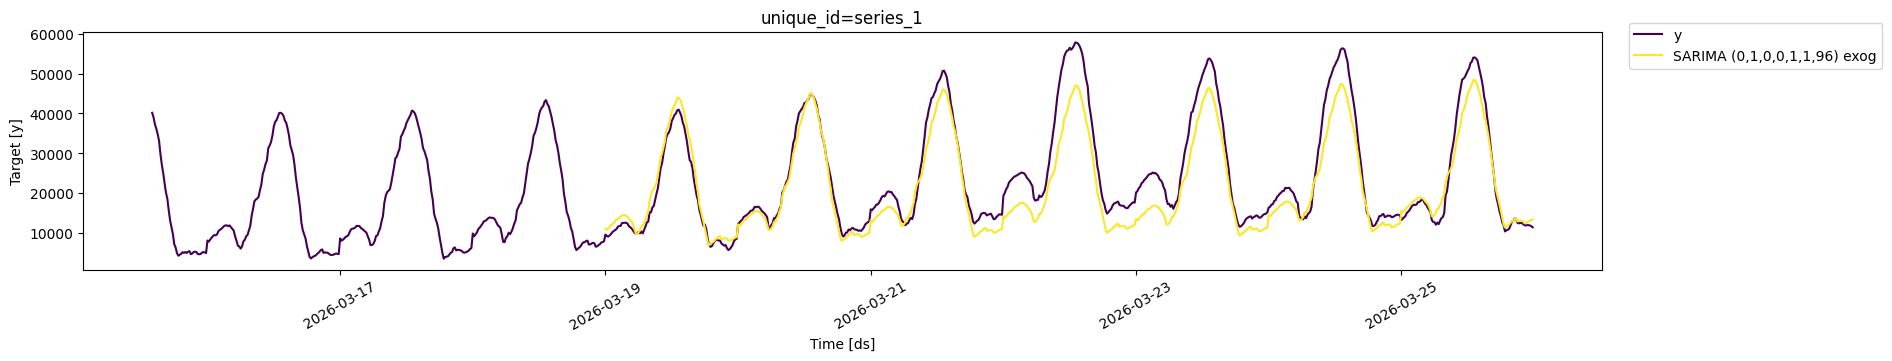

In [26]:
plot_series(
    df=filtered_data, 
    forecasts_df=exog_preds,  
    max_insample_length=1000, 
    palette="viridis")

### Metrics - last 7 days

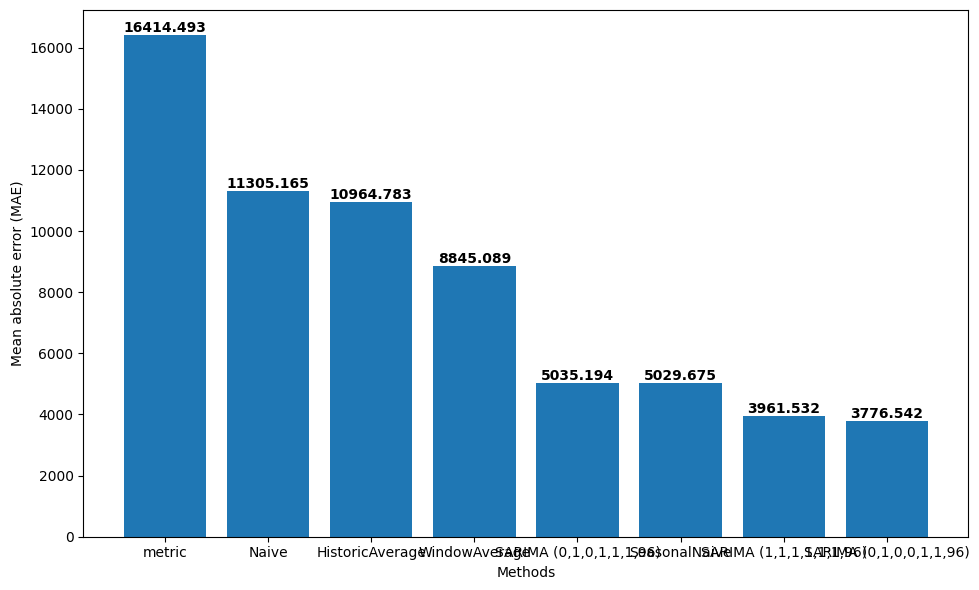

In [27]:
methods = metrics.columns[1:].tolist()  
values = metrics.iloc[0, 2:].tolist() 

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

### Cross Validation for naive and ARIMA

In [28]:
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=96*7),
    SeasonalNaive(season_length=96*7),
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96)"),
]

sf = StatsForecast(models=models, freq="15min")
cv_df = sf.cross_validation(
    h=horizon,
    df=filtered_data,
    n_windows=7,
    step_size=96,
    refit=True
)

cv_df.head()

,unique_id,ds,cutoff,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,0,1,1,96)"
0,series_1,2026-03-13 00:00:00,2026-03-12 23:45:00,5948.5,9467.2,25003.838047,21959.686756,20619.8,9856.666758
1,series_1,2026-03-13 00:15:00,2026-03-12 23:45:00,5935.1,9467.2,25003.838047,21959.686756,20822.5,10164.561157
2,series_1,2026-03-13 00:30:00,2026-03-12 23:45:00,6016.1,9467.2,25003.838047,21959.686756,21121.7,10434.493521
3,series_1,2026-03-13 00:45:00,2026-03-12 23:45:00,6157.4,9467.2,25003.838047,21959.686756,21494.1,10709.856940
4,series_1,2026-03-13 01:00:00,2026-03-12 23:45:00,6400.5,9467.2,25003.838047,21959.686756,22233.5,11119.967623


In [29]:
sf.fit(df=filtered_data)

StatsForecast(models=[Naive,HistoricAverage,WindowAverage,SeasonalNaive,SARIMA (0,1,0,0,1,1,96)])

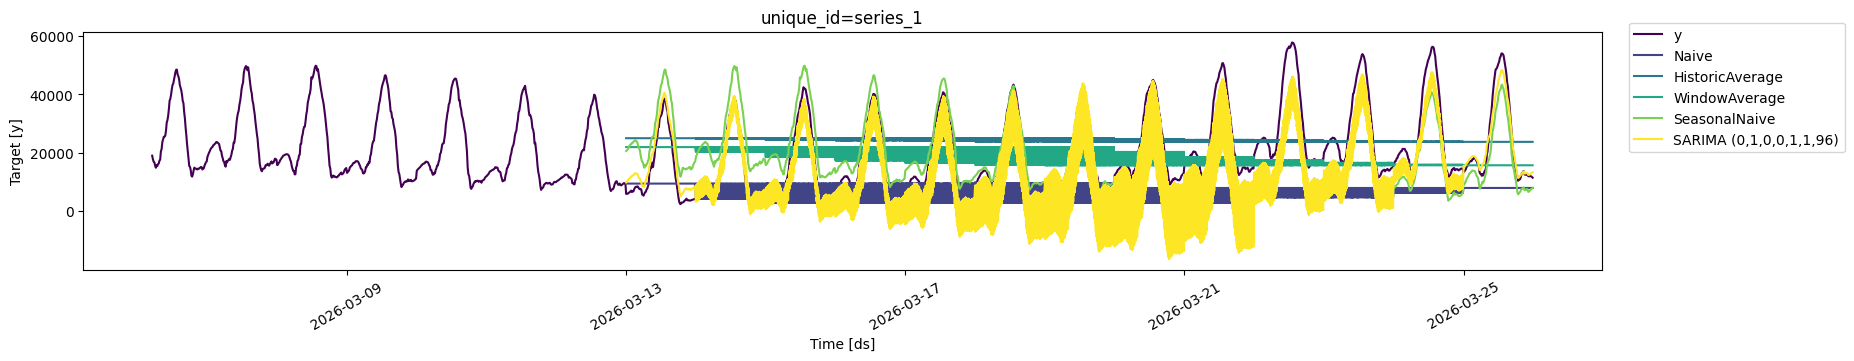

In [30]:
plot_series(
    df=filtered_data, 
    forecasts_df=cv_df.drop(["y", "cutoff"], axis=1), 
    max_insample_length=1900, 
    palette="viridis")

In [31]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval = cv_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,0,1,1,96)"
0,mae,14819.511798,12203.931965,10862.102924,7048.432696,8532.487193


### Cross Validation for SARIMA with exogenous variable

In [32]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,1,1,1,96) exog"),
]

sf = StatsForecast(models=models, freq="15min")
cv_df_exog = sf.cross_validation(
    h=horizon,
    df=data_with_exog,
    n_windows=7,
    step_size=96,
    refit=True
)
cv_df_exog.head()

,unique_id,ds,cutoff,y,"SARIMA (0,1,0,1,1,1,96) exog"
0,series_1,2026-03-13 00:00:00,2026-03-12 23:45:00,5948.5,10073.886320
1,series_1,2026-03-13 00:15:00,2026-03-12 23:45:00,5935.1,10383.463664
2,series_1,2026-03-13 00:30:00,2026-03-12 23:45:00,6016.1,10655.481306
3,series_1,2026-03-13 00:45:00,2026-03-12 23:45:00,6157.4,10932.383591
4,series_1,2026-03-13 01:00:00,2026-03-12 23:45:00,6400.5,11345.663887


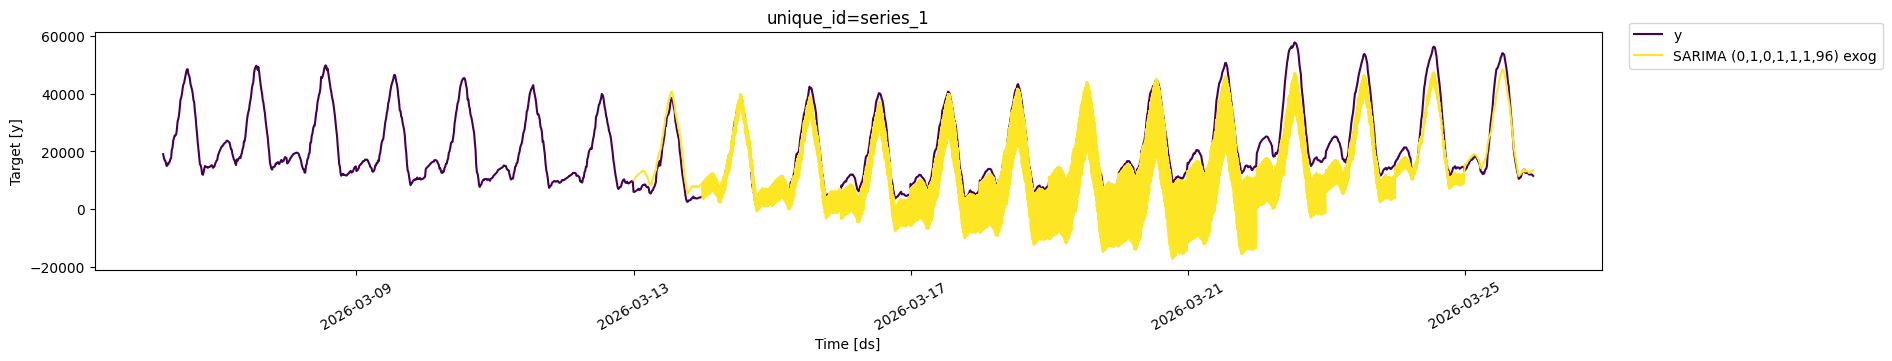

In [33]:
plot_series(
    df=data_with_exog, 
    forecasts_df=cv_df_exog.drop(["y", "cutoff"], axis=1), 
    max_insample_length=1900, 
    palette="viridis")

In [34]:
cv_eval_exog = evaluate(
    cv_df_exog.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval_exog = cv_eval_exog.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval_exog

,metric,"SARIMA (0,1,0,1,1,1,96) exog"
0,mae,8759.915888


### Simple Rolling Average

In [39]:
# 1. Define the parameters for the windows
start_cutoff = pd.to_datetime('2026-03-12 23:45:00')
n_windows = 7 
horizon = 96 * 7 

# --- FIX: Create the rolling average column first ---
# Assuming you want a 20-day rolling average (20 * 96 periods)
filtered_data['time'] = filtered_data['ds'].dt.time
filtered_data['rolling_avg_20d'] = (
    filtered_data.groupby(['unique_id', 'time'])['y']
    .transform(lambda x: x.rolling(window=20, min_periods=1).mean())
)
cv_rolling_list = []

# 2. Loop to create each cross-validation window
for i in range(n_windows):
    current_cutoff = start_cutoff + pd.Timedelta(days=i)
    forecast_start = current_cutoff + pd.Timedelta(minutes=15)
    forecast_end = current_cutoff + pd.Timedelta(days=7)
    
    # Filter the data for this specific forecast range
    window_preds = filtered_data[(filtered_data['ds'] >= forecast_start) & (filtered_data['ds'] <= forecast_end)].copy()
    
    # Add the cutoff column
    window_preds['cutoff'] = current_cutoff
    cv_rolling_list.append(window_preds)

# 3. Combine into a single dataframe
cv_rolling_df = pd.concat(cv_rolling_list).reset_index(drop=True)

# 4. Clean up columns (This will now work because the column exists)
cv_rolling_df = cv_rolling_df[['unique_id', 'ds', 'cutoff', 'y', 'rolling_avg_20d']]

print(f"Generated windows for cutoffs: {cv_rolling_df['cutoff'].unique()}")
cv_rolling_df.head()

Generated windows for cutoffs: <DatetimeArray>
['2026-03-12 23:45:00', '2026-03-13 23:45:00', '2026-03-14 23:45:00',
 '2026-03-15 23:45:00', '2026-03-16 23:45:00', '2026-03-17 23:45:00',
 '2026-03-18 23:45:00']
Length: 7, dtype: datetime64[ns]


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_81603/971884181.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['time'] = filtered_data['ds'].dt.time
/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_81603/971884181.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['rolling_avg_20d'] = (


,unique_id,ds,cutoff,y,rolling_avg_20d
0,series_1,2026-03-13 00:00:00,2026-03-12 23:45:00,5948.5,18491.81
1,series_1,2026-03-13 00:15:00,2026-03-12 23:45:00,5935.1,19200.62
2,series_1,2026-03-13 00:30:00,2026-03-12 23:45:00,6016.1,19801.90
3,series_1,2026-03-13 00:45:00,2026-03-12 23:45:00,6157.4,20269.45
4,series_1,2026-03-13 01:00:00,2026-03-12 23:45:00,6400.5,20907.54


In [40]:
evaluate(
    cv_rolling_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)

,unique_id,metric,rolling_avg_20d
0,series_1,mae,4713.281628


In [44]:
filtered_data.drop(columns={"rolling_avg_20d", "time"}, inplace=True)

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_81603/110791923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(columns={"rolling_avg_20d", "time"}, inplace=True)


## Trying TBATS

In [45]:
filtered_data['y'] = filtered_data['y'] / 1000

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_81603/1393424622.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['y'] = filtered_data['y'] / 1000


In [46]:
models = [
    AutoTBATS(96, use_boxcox=None, bc_lower_bound=0.0, bc_upper_bound=1.0, use_trend=None, use_damped_trend=None, use_arma_errors=True, alias='AutoTBATS')
]

sf = StatsForecast(models=models, freq="15min")
cv_df_tbats = sf.cross_validation(
    h=horizon,
    df=filtered_data,
    n_windows=7,
    step_size=96,
    refit=True
)

cv_df_tbats.head()

,unique_id,ds,cutoff,y,AutoTBATS
0,series_1,2026-03-13 00:00:00,2026-03-12 23:45:00,0.005948,0.010074
1,series_1,2026-03-13 00:15:00,2026-03-12 23:45:00,0.005935,0.010770
2,series_1,2026-03-13 00:30:00,2026-03-12 23:45:00,0.006016,0.011579
3,series_1,2026-03-13 00:45:00,2026-03-12 23:45:00,0.006157,0.012284
4,series_1,2026-03-13 01:00:00,2026-03-12 23:45:00,0.006400,0.013002


In [47]:
filtered_data['y'] = filtered_data['y'] * 1000

cv_df_tbats['y'] = cv_df_tbats['y'] * 1000
cv_df_tbats['AutoTBATS'] = cv_df_tbats['AutoTBATS'] * 1000

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_81603/952483533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['y'] = filtered_data['y'] * 1000


In [48]:
evaluate(
    cv_df_tbats.drop(["cutoff"], axis=1),
    metrics=[mae],
)

,unique_id,metric,AutoTBATS
0,series_1,mae,166.557624


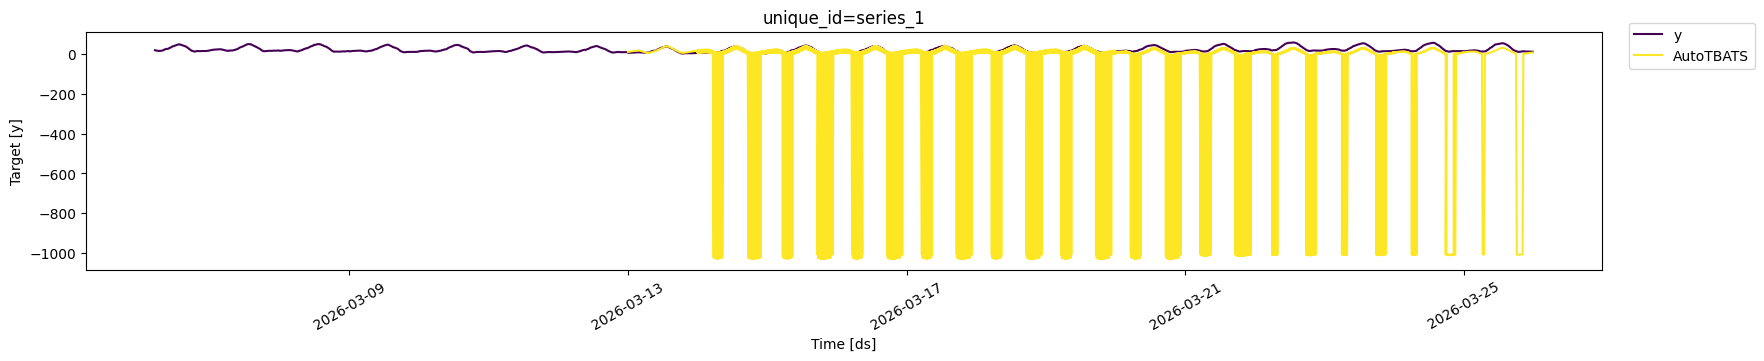

In [49]:
plot_series(
    df=filtered_data, 
    forecasts_df=cv_df_tbats.drop(["y", "cutoff"], axis=1), 
    max_insample_length=1900, 
    palette="viridis")

In [50]:
sf.fit(df=filtered_data)

StatsForecast(models=[AutoTBATS])

In [51]:
sf.fitted_[0][0].model_['aic']

np.float64(40609.88676451699)

## Comparing AIC

In [52]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)"),
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96)"),
    AutoTBATS(96, use_boxcox=None, bc_lower_bound=0.0, bc_upper_bound=1.0, use_trend=None, use_damped_trend=None, use_arma_errors=True, alias='AutoTBATS'),
]
models_with_exog = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96) exog"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96) exog")
]
sf = StatsForecast(models=models, freq="15min")
sf.fit(df=filtered_data)

StatsForecast(models=[SARIMA (0,1,0,1,1,1,96),SARIMA (1,1,1,1,1,1,96),SARIMA (0,1,0,0,1,1,96),AutoTBATS])

In [53]:
for i, model in enumerate(sf.fitted_[0]):
    model_name = sf.models[i]
    if 'aic' in model.model_:
        print(f"{model_name} AIC: {model.model_['aic']:.2f}")
    else:
        print(f"{model_name} does not support AIC.")

SARIMA (0,1,0,1,1,1,96) AIC: 8883.98
SARIMA (1,1,1,1,1,1,96) AIC: nan
SARIMA (0,1,0,0,1,1,96) AIC: 8968.61
AutoTBATS AIC: 40609.89


In [54]:
sf_exog = StatsForecast(models=models_with_exog, freq="15min")
sf_exog.fit(df=data_with_exog)

StatsForecast(models=[SARIMA (0,1,0,1,1,1,96) exog,SARIMA (1,1,1,1,1,1,96) exog])

In [55]:
for i, model in enumerate(sf_exog.fitted_[0]):
    model_name = sf_exog.models[i]
    if 'aic' in model.model_:
        print(f"{model_name} AIC: {model.model_['aic']:.2f}")
    else:
        print(f"{model_name} does not support AIC (e.g., Naive/Rolling)")

SARIMA (0,1,0,1,1,1,96) exog AIC: 77779.83
SARIMA (1,1,1,1,1,1,96) exog AIC: nan
